<a href="https://colab.research.google.com/github/TorbjornLarsson/SCDA/blob/main/Lab3_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab exercise 3: Eigenvalues and SVD

## Part 2: Low rank approximation and dimensionality reduction with SVD

There are many important applications in data analysis where SVD is used. One such application has to do with dimensionality reduction. If we have a big data set with many variables (stored as a big matrix), it may be reasonable to think that not all of the variables are equally important for the problem, and that it can therefore be possible to reduce the dimensionality of the problem. To do this, we can use the SVD. Here, we will look at one such example, namely image compression.

### Image compression

In [1]:
from google.colab import files

print("Vänligen ladda upp filen 'stinkbug.png' nu:")
uploaded = files.upload()

Vänligen ladda upp filen 'stinkbug.png' nu:


Saving stinkbug.png to stinkbug.png


We will here go through dimensionality reduction on a stinkbug image, step by step, using SVD. This is one way of compressing images.

_1.1) First, import the image by running the cell below. Make sure that you have saved the image in the working directory._

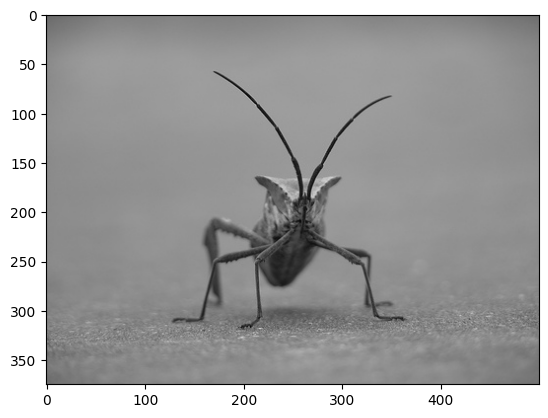

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('stinkbug.png')
plt.imshow(img, cmap='gray')

_1.2) Unfortunately, the image is stored as a 3D-array, as you can see if you check the shape of ${\tt img}$ with ``np.shape()``. Check the shape of the image._

In [3]:
print(np.shape(img))


(375, 500, 3)


The reason it is a 3D-array is due to the way images are normally stored. It is possible to do SVD on 3D-matrices, but it is not part of this course. To make it simpler we will therefore work with a 2D-array.<br>

_1.3) Convert the 3D-image to a 2D-array by running the code snippet below. This will create a new image (${\tt GrayImage}$) stored in a 2D-array._

In [4]:
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]
GrayImage = R * 0.2126 + G * 0.7152 + B * 0.0722

_1.4) Check the shape of ${\tt GrayImage}$, and plot the image again._

(375, 500)


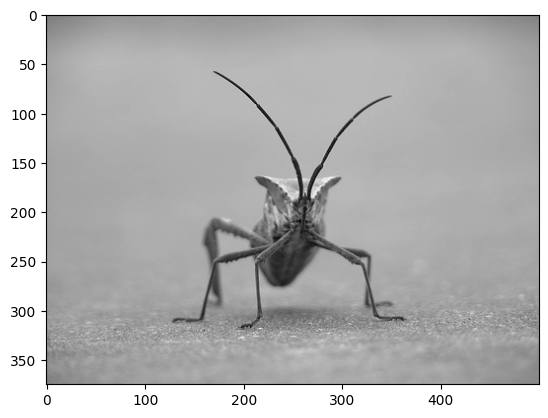

In [5]:
print(np.shape(GrayImage))
plt.imshow(GrayImage, cmap='gray')

<b>Compression using SVD</b><br>
_1.5) We will now use SVD to compress the image, which is equal to a dimensionality reduction. We will transform the image-matrix to matrices $U, S$ and $V$, such that $A = U\cdot S \cdot V^T$. The idea is to "cut off" some of the singular values, and then go back to the image again by multiplying the "cut-off" matrices (this is described in more detail below). Run the cell below to perform the SVD._

In [6]:
U, S, Vt = np.linalg.svd(GrayImage, full_matrices = False)

According to the theory, if $A$ is $m \times n$, then:<br>
- $U$, should be $m \times m$
- $S$, should be $m \times n$
- $V^T$, should be $n \times n$

_1.6) Check the shapes of $U$, $S$ and $V^T$. Are the shapes correct?_<br>

Hint: What is $m$ and $n$ in this case (the shape of $A$)?

In [8]:
print("Shape of U:", np.shape(U))
print("Shape of S:", np.shape(S))
print("Shape of Vt:", np.shape(Vt))

Shape of U: (375, 375)
Shape of S: (375,)
Shape of Vt: (375, 500)


Clearly, $S$ is not a matrix, but a vector. The reason is that only the singular values, no zeros, are stored.<br>
The size of matrix $V$ is also wrong. The reason is that we put `full_matrices=False` in the SVD-call, which generates the so called "reduced" or "economical" form.
<br><br>

_1.7) SVD always generates the singular values in descending order. The smaller values contribute less in the multiplication $USV^T$, i.e. contribute less to the matrix $A$. Check the size of the singular values by plotting them (with 1, 2, 3, ... up to the the number singular values on the x-axis)._

Hint: Create an x-axis with the command `x=np.arange(1,len(S)+1)` and then plot the singular values stored in $S$ using the command `plt.plot(x,S)`.

Text(0, 0.5, 'Singular Value')

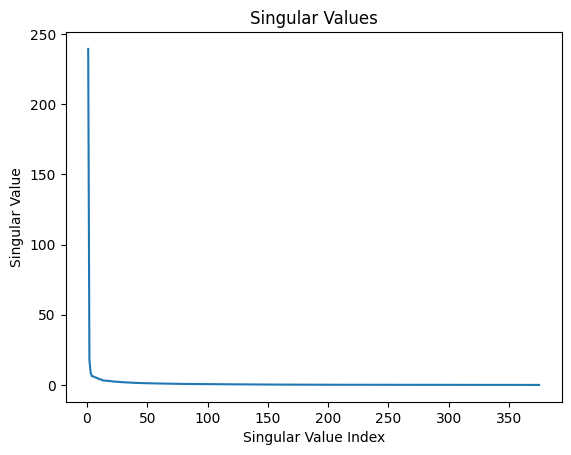

In [9]:
x = np.arange(1, len(S) + 1)
plt.plot(x, S)
plt.title("Singular Values")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")

_1.8) The singular values are obviously only big in the beginning, and the get smaller very rapidly. Change the plot to only look at the first 10 singular values. You can do this by adjusting the plot-command to `plt.plot(x[:10],S[:10])`. Or just look at singular values from the tenth and up, use `plt.plot(x[10:],S[10:])`.<br>
Try it!_

Text(0, 0.5, 'Singular Value')

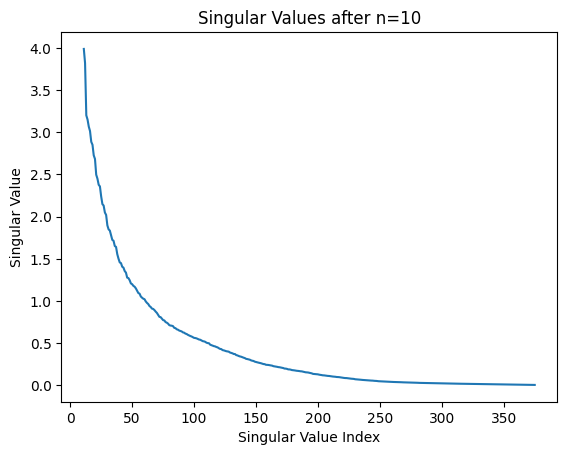

In [11]:
x = np.arange(1, len(S) + 1)

plt.plot(x[10:],S[10:])
plt.title("Singular Values after n=10")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")


If we cut-off the "tail" and recreate the matrix $A_c=U_cS_cV^T_c$, where $U_c, S_c, V^T_c$ are the "cut-off" matrices, it shouldn't affect the matrix that much as we just remove small singular values.<br>

Let's say we decide to keep the $r$ first singular values. We will the have to keep
- the $r$ first columns of $U$
- the $r$ first singular values in $S$
- the $r$ first rows in $V^T$

_1.9) Let $r=20$ and try to create $U_c$, $S_c$ and $V^T_c$. Also check the shape of the new matrices._

In [12]:
r = 20

U_c = U[:, :r]
S_c = S[:r]
Vt_c = Vt[:r, :]

print("Shape of U_c:", np.shape(U_c))
print("Shape of S_c:", np.shape(S_c))
print("Shape of Vt_c:", np.shape(Vt_c))


Shape of U_c: (375, 20)
Shape of S_c: (20,)
Shape of Vt_c: (20, 500)


We have now changed the dimension of the image from 375 to $r$.<br><br>

_1.10) Create a new image-matrix by multiplying $A_c = U_cS_cV^T_c$. According to the `np.linalg.svd` reference manual, the multiplication can be done according to `np.dot(U * S, Vt)` for the reduced form of SVD. Do the multiplication and create a new image-matrix $A_c$. Then use `plt.imshow(A_c, cmap='gray')` to draw the compressed image. Does it look a lot different from the original image?_

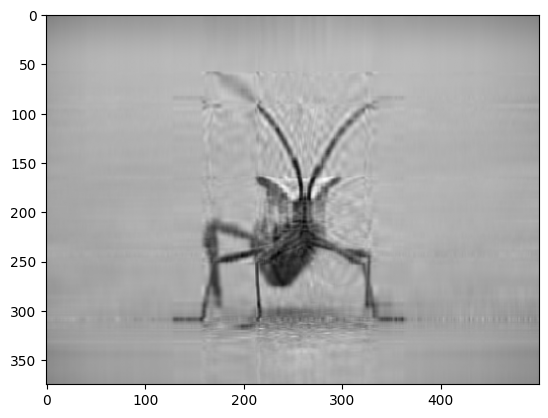

In [13]:
A_c = np.dot(U_c * S_c, Vt_c)
plt.imshow(A_c, cmap='gray')


_1.11) Try different degrees of dimensionality reduction by varying the parameter $r$. How many dimensions can you remove if the image should still look acceptable?_

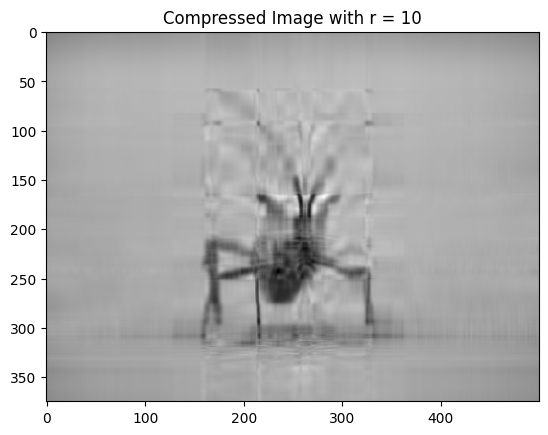

In [14]:
r_new = 10  # Exempel: Halvera r från 20 till 10

# Skapa de avklippta matriserna med det nya r-värdet
U_c_new = U[:, :r_new]
S_c_new = S[:r_new]
Vt_c_new = Vt[:r_new, :]

# Återskapa bilden
A_c_new = np.dot(U_c_new * S_c_new, Vt_c_new)

# Visa den komprimerade bilden
plt.imshow(A_c_new, cmap='gray')
plt.title(f"Compressed Image with r = {r_new}")
plt.show()


<h3>Check This Out</h3>
You can play around with image compression on real colour images here: <a href="https://timbaumann.info/svd-image-compression-demo/" target="_blank">Image compression with SVD demo</a>. You can see the size of the singular values for different images, and also change the compression with a little ruler.

### Principal Component Analysis (PCA)

Another well-known dimensionality reduction technique in data analysis is Principal Component analysis, PCA. The idea is to find the directions where most variation (the covariance) is located. Often it's possible to find two axes where most of the data variation is, and then reduce the dimensionality to two. PCA is also based on the SVD-decomposition.

Here, we engage in practice with point clouds in both two and three dimensions. In the cell below, we are creating a 2D random point cloud and plotting it:

(np.float64(-10.128856847816367),
 np.float64(8.262119319594936),
 np.float64(-9.005820838613761),
 np.float64(6.811665477738738))

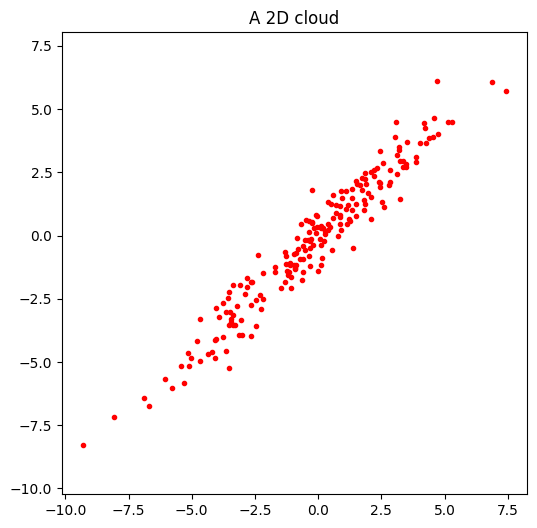

In [15]:
# a 2D cloud
import numpy as np
import matplotlib.pyplot as plt

x = 0.5*np.random.normal(size = 200)
y = 4 * np.random.normal(size = 200)
A = np.array([x,y])
# rotate the points anticlockwise by pi/4
R  = np.array([[np.cos(np.pi/4),np.sin(np.pi/4)],[-np.sin(np.pi/4),np.cos(np.pi/4)]])
A = R@A
plt.figure(figsize = (6, 6))
plt.scatter(A[0,:],A[1,:],marker = '.',color = 'red')
plt.title("A 2D cloud")
plt.axis('equal')

To project these points to the first principal direction (say $u_1$), compute the SVD of $A$, and compute the rank one approximation $A_1 = U_1\Sigma_1 V_1$. Finally plot $A_1$:

(np.float64(-9.74928605649054),
 np.float64(7.486698202950972),
 np.float64(-9.380596243716266),
 np.float64(7.203572921494507))

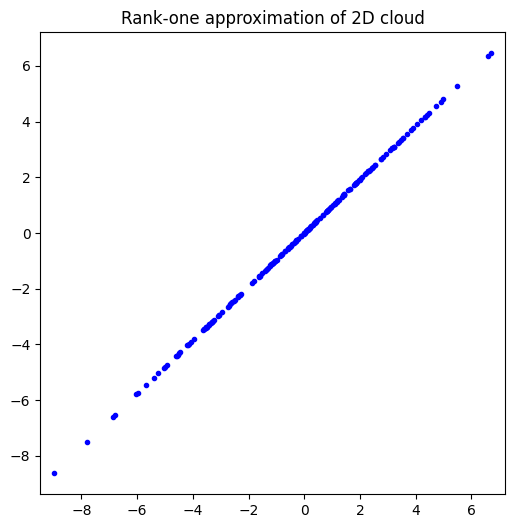

In [16]:
U_2D, S_2D, Vt_2D = np.linalg.svd(A)

# Rank-one approximation
# Take the first singular value and corresponding vectors
U1 = U_2D[:, 0:1] # First column of U
S1 = S_2D[0]      # First singular value
V1 = Vt_2D[0:1, :] # First row of Vt

A1 = U1 @ np.array([[S1]]) @ V1

plt.figure(figsize = (6, 6))
plt.scatter(A1[0,:],A1[1,:],marker = '.',color = 'blue')
plt.title("Rank-one approximation of 2D cloud")
plt.axis('equal')

Since $A$ is a $2\times 200$ matrix, its rank-2 approximation will effectively yield the original matrix $A$ itself. Now, let's work with a random 3D point cloud generated using the following code:

Text(0.5, 0.92, 'A 3D cloud')

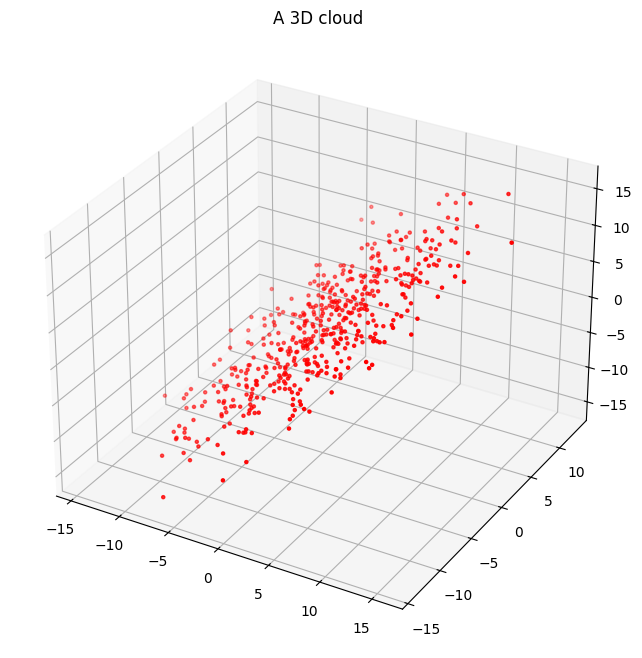

In [18]:
# a 3D cloud
x = 0.5*np.random.normal(size = 500)
y = 8*np.random.normal(size = 500)
z = 4*np.random.normal(size = 500)
A = np.array([x,y,z])
c,s = np.cos(np.pi/4),np.sin(np.pi/4)
R1  = np.array([[c,s,0],[-s,c,0],[0,0,1]])
c,s = np.cos(-np.pi/4),np.sin(-np.pi/4)
R2  = np.array([[1,0,0],[0,c,s],[0,-s,c]])
c,s = np.cos(np.pi/2),np.sin(np.pi/2)
R3  = np.array([[c,0,s],[0,1,0],[-s,0,c]])
A = R1@R2@R3@A
# plot
fig = plt.figure(figsize = (8, 8))
ax = plt.axes(projection ="3d")
ax.scatter3D(A[0,:], A[1,:], A[2,:],color = 'red', marker ='.')
plt.title("A 3D cloud")

Compute the SVD of matrix $A$ and project this point cloud onto the first principal direction $u_1$ (reducing the dimension to 1). Then, project the points onto the plane formed by the first and second principal directions $u_1$ and $u_2$ (reducing the dimension to 2). For each scenario, create a plot illustrating the projected points:

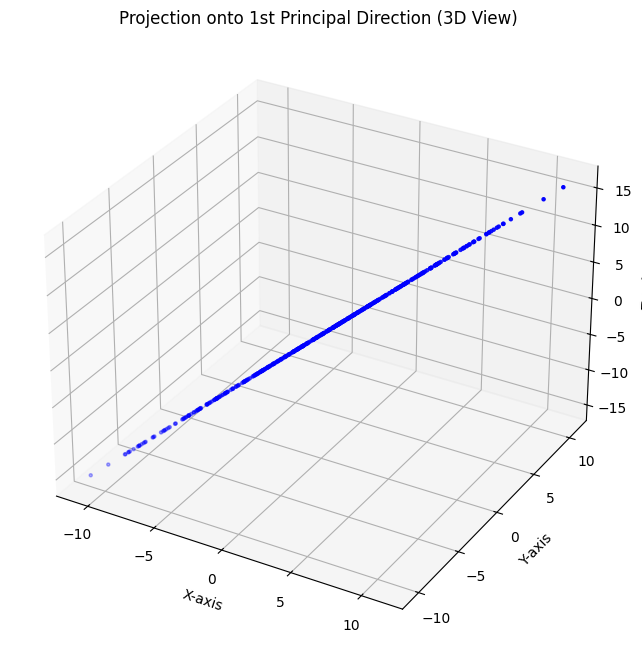

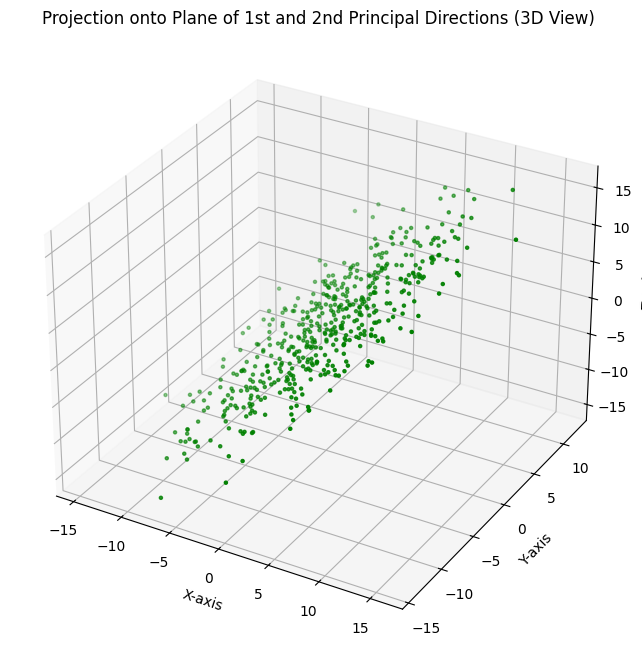

In [19]:
# Compute the SVD of the 3D matrix A
U_3D, S_3D, Vt_3D = np.linalg.svd(A)

# --- Projection onto the first principal direction (Dimension 1) ---
# Get the first principal direction (first column of U)
U1_3D = U_3D[:, 0:1]
# Get the first singular value
S1_3D = S_3D[0]
# Get the first row of Vt
V1_3D = Vt_3D[0:1, :]

# Reconstruct the rank-1 approximation
A_proj1 = U1_3D @ np.array([[S1_3D]]) @ V1_3D

# Plotting for Dimension 1 Projection
fig1 = plt.figure(figsize = (8, 8))
ax1 = plt.axes(projection = "3d")
ax1.scatter3D(A_proj1[0,:], A_proj1[1,:], A_proj1[2,:], color = 'blue', marker ='.')
ax1.set_title("Projection onto 1st Principal Direction (3D View)")
ax1.set_xlabel("X-axis")
ax1.set_ylabel("Y-axis")
ax1.set_zlabel("Z-axis")

# --- Projection onto the plane formed by the first and second principal directions (Dimension 2) ---
# Get the first two principal directions (first two columns of U)
U2_3D = U_3D[:, 0:2]
# Get the first two singular values
S2_3D = S_3D[0:2]
# Get the first two rows of Vt
V2_3D = Vt_3D[0:2, :]

# Reconstruct the rank-2 approximation
A_proj2 = U2_3D @ np.diag(S2_3D) @ V2_3D

# Plotting for Dimension 2 Projection
fig2 = plt.figure(figsize = (8, 8))
ax2 = plt.axes(projection = "3d")
ax2.scatter3D(A_proj2[0,:], A_proj2[1,:], A_proj2[2,:], color = 'green', marker ='.')
ax2.set_title("Projection onto Plane of 1st and 2nd Principal Directions (3D View)")
ax2.set_xlabel("X-axis")
ax2.set_ylabel("Y-axis")
ax2.set_zlabel("Z-axis")

plt.show()